# Análisis de Plataforma "Zuber"
---

Zuber es una nueva empresa de viajes compartidos que se está lanzando en Chicago. La tarea es encontrar patrones en la información disponible. Particularmente, se busca comprender las preferencias de los pasajeros y el impacto de los factores externos en los viajes.

Al trabajar con una base de datos, se analizarán los datos de los competidores y hará una prueba de hipótesis sobre el impacto del clima en la frecuencia de los viajes.

*Disclaimer*: "Zuber" no es una empresa real, ni el resto con las que se estará trabajando. La base y análisis de datos fueron construidos con fines puramente expositivos sobre conocimientos técnicos en python, así como de estadística descriptiva e inferencial. 

## 1. Preprocesamiento de los Datos

In [ ]:
# Se importan las librerías que se van a utilizar para la creación del modelo.
import pandas as pd
from scipy import stats as st
from matplotlib import pyplot as plt
import seaborn as sns 

In [ ]:
# Se cargan las bases de datos en formato "CSV".
df_company = pd.read_csv("/datasets/project_sql_result_01.csv")

df_trips = pd.read_csv("/datasets/project_sql_result_04.csv")

df_weather = pd.read_csv("/datasets/project_sql_result_07.csv")

In [4]:
# Se muestran las características de los tres dataframes para ver potenciales valores ausentes, así como verificar el tipo de dato
# de cada columna.

# df_company no tiene valores nulos y tiene los tipos de datos correctos en sus columnas. 
print(df_company.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB
None


In [24]:
# df_trips no tiene valores nulos y tiene los tipos de datos correctos en sus columnas.
print(df_trips.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB
None
Edgewater             1
Jackson Park          1
East Side             1
Brighton Park         1
Chinatown             1
                     ..
Humboldt Park         1
Washington Heights    1
Old Town              1
Albany Park           1
South Chicago         1
Name: dropoff_location_name, Length: 94, dtype: int64


In [6]:
# df_weather no tiene valores nulos. Sin embargo, la columna "start_ts" tiene formato "object" (o "string"). Es necesario convertirla a
# datetime. Esto lo haremos posteriormente en la sección de prueba de hipótesis. 
print(df_weather.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   start_ts            1068 non-null   object 
 1   weather_conditions  1068 non-null   object 
 2   duration_seconds    1068 non-null   float64
dtypes: float64(1), object(2)
memory usage: 25.2+ KB
None


In [7]:
# Una vez verificado que no hay valores ausentes en ninguno de los dataframes, pasemos a corroborar si es que existen valores duplicados.

# df_company no tiene valores duplicados.
df_company.duplicated().sum()

0

In [8]:
# df_trips no tiene valores duplicados.
df_trips.duplicated().sum()

0

In [ ]:
# df_weather tiene 197 valores duplicados. Es necesario eliminarlos en orden a representar correctamente los datos en los ejercicios posteriores.
# Mantenerlos podría sobre o subestimar tendencias o patrones importantes en el comportamiento de los datos.
print(df_weather.duplicated().sum())
df_weather = df_weather.drop_duplicates()
print(df_weather.duplicated().sum())
print(df_weather.info())

# El dataframe pasa a quedarse con 871 observaciones o datos. 

197
0
<class 'pandas.core.frame.DataFrame'>
Int64Index: 871 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   start_ts            871 non-null    object 
 1   weather_conditions  871 non-null    object 
 2   duration_seconds    871 non-null    float64
dtypes: float64(1), object(2)
memory usage: 27.2+ KB
None


## 2. Análisis Exploratorio de los Datos

In [10]:
# Procedamos ahora con un repaso de algunas estadísticas básicas de cada uno de los dataframes: sus medidas de tendencia central, 
# el primer, segundo y tercer cuartil, así como los valores mínimos y máximos. Ello nos permitirá darnos una idea más clara de cómo
# se distribuyen los datos.

# En df_company, podemos ver una distribución asimétrica con un sesgo positivo a la derecha, en cuanto que la media es 
# significativamente mayor que la mediana. 
df_company.describe()

,trips_amount
count,64.000000
mean,2145.484375
std,3812.310186
min,2.000000
25%,20.750000
50%,178.500000
75%,2106.500000
max,19558.000000


In [11]:
# En df_trips, podemos ver una distribución asimétrica con un sesgo positivo a la derecha, en cuanto que la media es 
# significativamente mayor que la mediana. 
df_trips.describe()

,average_trips
count,94.000000
mean,599.953728
std,1714.591098
min,1.800000
25%,14.266667
50%,52.016667
75%,298.858333
max,10727.466667


In [12]:
# En df_weather, podemos ver una distribución bastante más simétrica, asemejándose más a una campana de Gauss, en cuanto
# que el valor de la media es aproximado al de la mediana. 
df_weather.describe()

,duration_seconds
count,871.000000
mean,2096.308840
std,782.274717
min,0.000000
25%,1440.000000
50%,2015.000000
75%,2584.000000
max,7440.000000


In [13]:
# Ahora exponemos dos tablas: la primera que muestra el top 10 de empresas de taxis con más número de viajes realizados
# 15 y 16 de noviembre de 2017, mientras la segunda el top 10 barrios de chicago con los promedios más altos de 
# viajes que terminaron en noviembre de 2017. Igualmente se visualizan dos gráficos de barras para mostrar
# de mejor manera los resultados de cada tabla.

# Primera tabla: 
df_cpny_top_10 = df_company.sort_values(by='trips_amount', ascending=False).head(10)
df_cpny_top_10

,company_name,trips_amount
0,Flash Cab,19558
1,Taxi Affiliation Services,11422
2,Medallion Leasing,10367
3,Yellow Cab,9888
4,Taxi Affiliation Service Yellow,9299
5,Chicago Carriage Cab Corp,9181
6,City Service,8448
7,Sun Taxi,7701
8,Star North Management LLC,7455
9,Blue Ribbon Taxi Association Inc.,5953


In [14]:
# Segunda tabla:
df_trips_top_10 = df_trips.sort_values(by='average_trips', ascending=False).head(10)
df_trips_top_10

,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667
3,West Loop,5163.666667
4,O'Hare,2546.900000
5,Lake View,2420.966667
6,Grant Park,2068.533333
7,Museum Campus,1510.000000
8,Gold Coast,1364.233333
9,Sheffield & DePaul,1259.766667


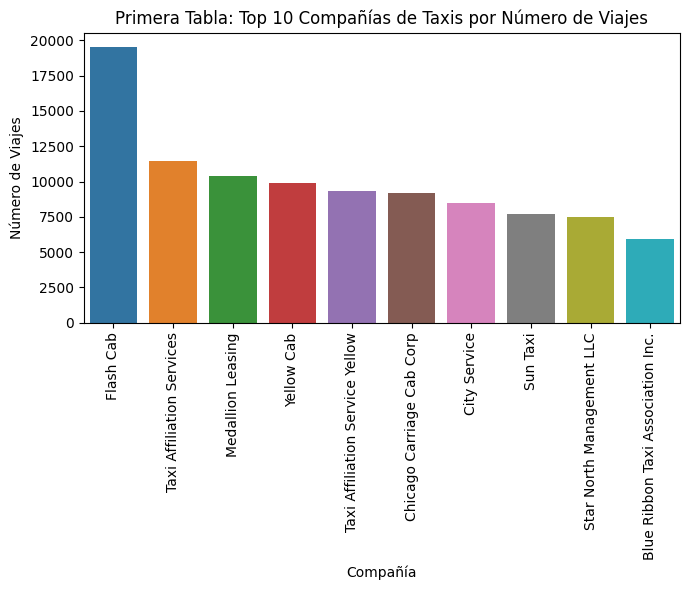

In [15]:
plt.figure(figsize=(7,6))
sns.barplot(
    data=df_cpny_top_10,
    x='company_name',
    y='trips_amount'
)

plt.title('Primera Tabla: Top 10 Compañías de Taxis por Número de Viajes')
plt.xlabel('Compañía')
plt.ylabel('Número de Viajes')
plt.xticks(rotation=90)
plt.tight_layout()  
plt.show()

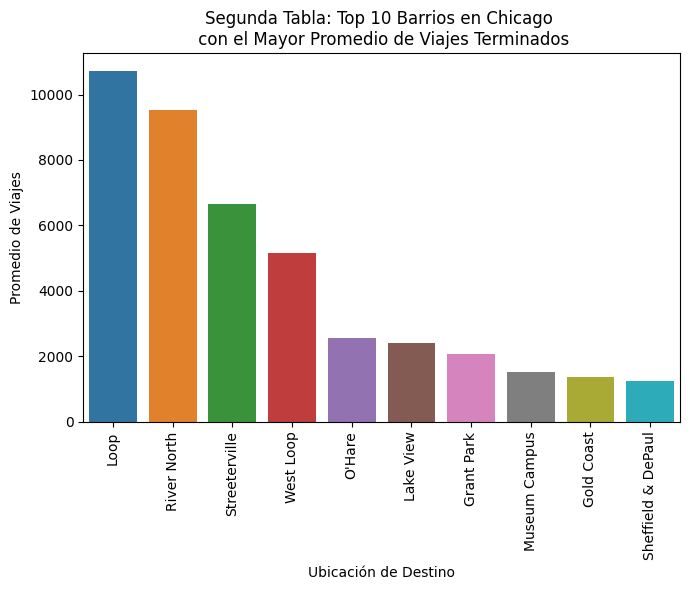

In [16]:
plt.figure(figsize=(7,6))
sns.barplot(
    data=df_trips_top_10,
    x='dropoff_location_name',
    y='average_trips'
)

plt.title('Segunda Tabla: Top 10 Barrios en Chicago \n con el Mayor Promedio de Viajes Terminados')
plt.xlabel('Ubicación de Destino')
plt.ylabel('Promedio de Viajes')
plt.xticks(rotation=90)
plt.tight_layout()  
plt.show()


## 3. Prueba de Hipótesis
---
La hipótesis que deseamos probar es la siguiente: "La duración promedio de los viajes desde el Loop hasta 
el Aeropuerto Internacional O'Hare cambia los sábados lluviosos". Sin embargo, antes de ello, cabe hacer un filtrado
para obtener dos muestras que será necesario contraponer: 1) aquella que contenga solamente los datos de 
la duración de los viajes en los sábados lluviosos *versus* 2) la que contenga únicamente la información del resto 
de la semana con buen clima.

Ahora bien este diseño presupone que la prueba de hipótesis será aplicada a dos muestras independientes. Esto es así
porque 1) no estamos haciendo una comparación temporal del cambio de las unidades observadas tras un determinado evento
o la introducción de un factor "x" ni 2) se busca contrastar la media de la muestra con un valor conocido o teórico. 
Para ejemplifcarlo con una misma situación, mientras el primer caso se aplicaría a circunstancias como el peso de las mismas personas 
antes y después de una dieta para evaluar si esta última fue efectiva, el segundo, por su lado, buscaría ver si el peso promedio de esas personas es diferente de 70 kg (valor teórico). Sin embargo, en nuestro ejercicio, se está en un contexto distinto, ya que se 
tienen dos grupos completamente diferentesa para comparar: la duración de viajes en sábados lluviosos vs otros días. Se quiere ver
si la duración de la primera agrupación (sábados lluviosos) difiere de la otra (resto de días) con significancia estadística. De ahí la 
necesidad de aplicar una prueba de hipótesis a dos muestras independientes.


In [17]:
# Se visualiza el dataframe y los valores únicos por los cuales se va a filtrar posteriormente. 

print(df_weather.head(5))
print(df_weather['weather_conditions'].unique())

              start_ts weather_conditions  duration_seconds
0  2017-11-25 16:00:00               Good            2410.0
1  2017-11-25 14:00:00               Good            1920.0
2  2017-11-25 12:00:00               Good            1543.0
3  2017-11-04 10:00:00               Good            2512.0
4  2017-11-11 07:00:00               Good            1440.0
['Good' 'Bad']


In [18]:
# Ahora es el momento de convertir la columna "start_ts" a formato datetime para que de esa manera sea más fácil
# filtrar los días sábados que además hayan tenido el valor "Bad" en la columna "weather_conditions". 
df_weather['start_ts'] = pd.to_datetime(df_weather['start_ts'])

# A partir de un ejercicio de ingenieria de características, crear una columna que sólo contenga los días de la semana
df_weather['day_of_week'] = df_weather['start_ts'].dt.dayofweek  

In [19]:
# Grupo 1: Sábados lluviosos
sabados_lluviosos = df_weather[
    (df_weather['day_of_week'] == 5) & 
    (df_weather['weather_conditions'] == 'Bad')  
]

# Grupo 2: El resto (todos los demás viajes)
resto = df_weather[
    ~((df_weather['day_of_week'] == 5) & 
      (df_weather['weather_conditions'] == 'Bad'))
]

In [20]:
# Una vez filtrados los dos dataframes, hay que hacer una ulterior filtración para que únicamente tengan los valores
# de las duraciones. Esto permitirá transformar cada grupo en un objeto Series y, por tanto, someterlos a la prueba 
# de hipótesis sin complicación alguna. 

duracion_sabados_lluviosos = sabados_lluviosos['duration_seconds']
duracion_resto = resto['duration_seconds']

In [ ]:
# Se establece un nivel de confianza del 95%. Normalmente este es el nivel estándar a aplicar en fenómenos sociales.
# En medicina, el nivel de confianza debe ser mucho mayor, no menor a 99% (por ejemplo, en la elaboración de alguna
# vacuna). Sin embargo, cada uno en su contexto de aplicación tiene el grado de rigurosidad necesario para sacar 
# conclusiones certeras y tomar decisiones informadas. En nuestro caso, un nivel de confianza de 95% quiere decir,
# palabras más, palabras menos, que si repitiéramos nuestro análisis 100 veces con diferentes muestras 
# de la misma población, aproximadamente 95 de esas veces obtendríamos resultados que incluirían el verdadero valor de la población.
# Por tanto, tenemos un 95% de confianza en que las conclusiones que a continuación extraeremos son correctas. Ahora bien,
# es importante mencionar que nuestra prueba de hipótesis es bilateral, ya que no se pretende comprobar si la duración del
# trayecto aumenta o disminuye. La hipótesis nula en este sentido será que que no hay cambio en la duración de los trayectos, esto es, 
# sin importar que sean en sábados lluviosos, en tanto que la hipótesis alternativa afirma que sí hay cambio cuando se cumple esta 
# última condición.
 
alfa = .05 

resultado = st.ttest_ind(duracion_sabados_lluviosos, duracion_resto, equal_var=False)

print(f"p-value: {resultado.pvalue}")
if resultado.pvalue < alfa:
    print('Rechazamos H₀: La duración cambia en sábados lluviosos')
else:
    print('No rechazamos H₀: No hay evidencia de que la duración cambie')

# Se rechaza la hipótesis nula. Por tanto, puede afirmarse con 95% de confianza de que la duración de los trayectos de los viajes
# desde Loop hasta el Aeropuerto Internacional O'Hare cambia los sábados lluviosos".

# Sin embargo, parece que el hecho de saber que la duración cambia simplemente no nos da mucha información. Por tanto, procedamos
# con una última prueba de hipótesis para saber más precisamente si aumentó o disminuyó la duración del trayecto en los sábados lluviosos. 
# En este caso, la hipótesis nula postula que la duración de los traytectos no aumentó, mientras la alterntiva sostiene que sí aumentó.

resultado_2 = st.ttest_ind(duracion_sabados_lluviosos, duracion_resto, alternative='greater')

print(f"p-value: {resultado_2.pvalue}")
if resultado_2.pvalue < alfa:
    print('Rechazamos H₀: La duración sí aumenta en sábados lluviosos')
else:
    print('No rechazamos H₀: No hay evidencia de que la duración aumente')

# Se rechaza la hipótesis nula. Por tanto, puede afirmarse con 95% de confianza de que la duración de los trayectos de los viajes
# desde Loop hasta el Aeropuerto Internacional O'Hare aumenta los sábados lluviosos".

p-value: 7.397770692813658e-08
Rechazamos H₀: La duración cambia significativamente en sábados lluviosos
p-value: 3.698885346406829e-08
Rechazamos H₀: La duración sí aumenta significativamente en sábados lluviosos


# Conclusiones
---
Hay varias cuestiones que resaltar en las conclusiones. En primer lugar, a partir del análisis de las empresas competiduras de "Zuber", tenemos que "Flash Cab" no sólo se encuentra en primer lugar, sino que rebasa por mucho al resto de las nueve empresas con mayor número de viajes los días 15 y 16 de noviembre de 2017. Habría que revisar más a profundidad si ello se debió a factores casuales o que "Flash Cab" realmente tenga un componente diferenciador que le ponga por encima de las demás (y en este último caso, examinar cuáles serían). Por otro lado, respecto a los barrios con mayor promedio de viajes terminados en noviembre de 2017, está Loop a la cabeza. Se recomienda a "Zuber", no obstante, quedarse en el rango de estos diez barrios, puesto que ya constituye una selección de un total de 94. Esta circunscripción le permitirá ahorrar recursos y, a la vez, participar en zonas con alta actividad en la demanda de transporte. Finalmente, la prueba de hipótesis demostró que los viajes desde Loop hasta el Aeropuerto Internacional O'Hare aumenta los sábados lluviosos. Como es bien sabido, la lluvia es un factor que estimula considerablemente el tráfico en grandes ciudades. Por tanto, en estas circunstancias puede existir una alta demanda de personas que estén en Loop esperando un taxi al aeropuesto, pero que no haya una suficiente cantidad de estos para cubrirla. En dichas situaciones puede ser un área de oportunidad para "Zuber" poner a disposición un mayor número de automóviles que lo usual, centrándose en las rutas que vayan de Loop al aeropuerto y viceversa. Esta serie de medidas brindarán a Zuber diversas áreas de oportunidad para competir mejor con el resto de empresas de taxis. 